<a href="https://colab.research.google.com/github/sofyadmitrieva/python-ML-basics/blob/main/clustering_hw_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

# Часть 1 K‑Means

In [2]:
# 1. Загрузите данные
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-04 17:55:27--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv.1’

wineqr.csv.1        100%[===================>]  82.17K  --.-KB/s    in 0.01s   

2026-05-04 17:55:27 (5.52 MB/s) - ‘wineqr.csv.1’ saved [84143/84143]



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('wineqr.csv')

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
#  удалите столбец quality,
X = df.drop(columns=['quality'])

In [7]:
# выполните масштабирование (StandardScaler).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Для K от 2 до 10:
# Обучите K‑Means
# Вычислите WCSS и коэффициент силуэта

range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


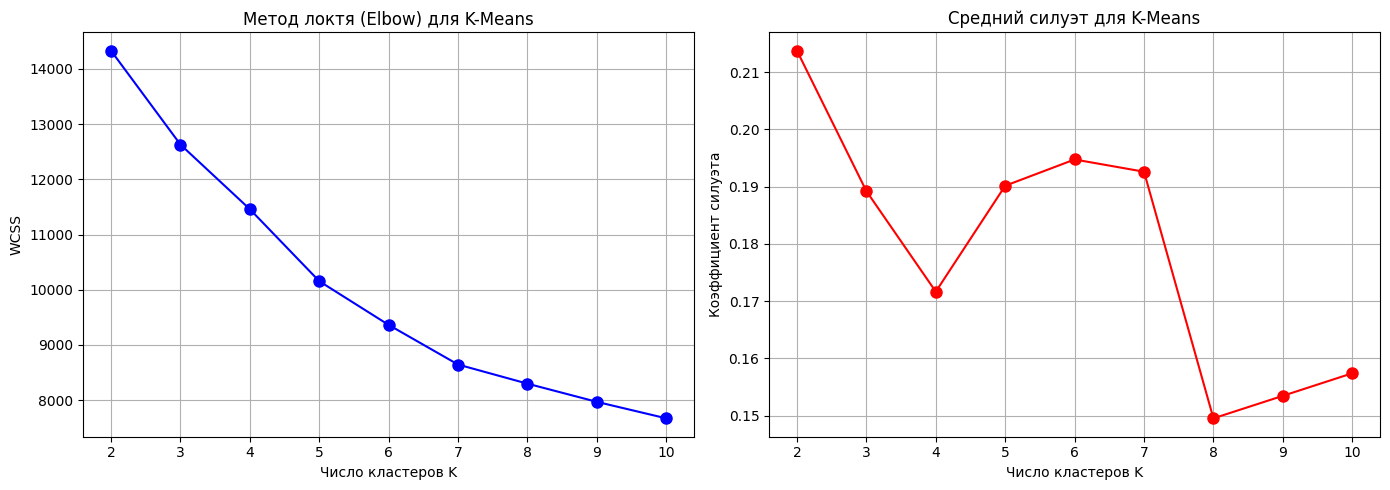

In [9]:
# Постройте два графика: метод локтя (WCSS) и средний силуэт.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Выберите оптимальное K по силуэту.

optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [12]:
# Обучите финальную модель K‑Means с выбранным K.

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

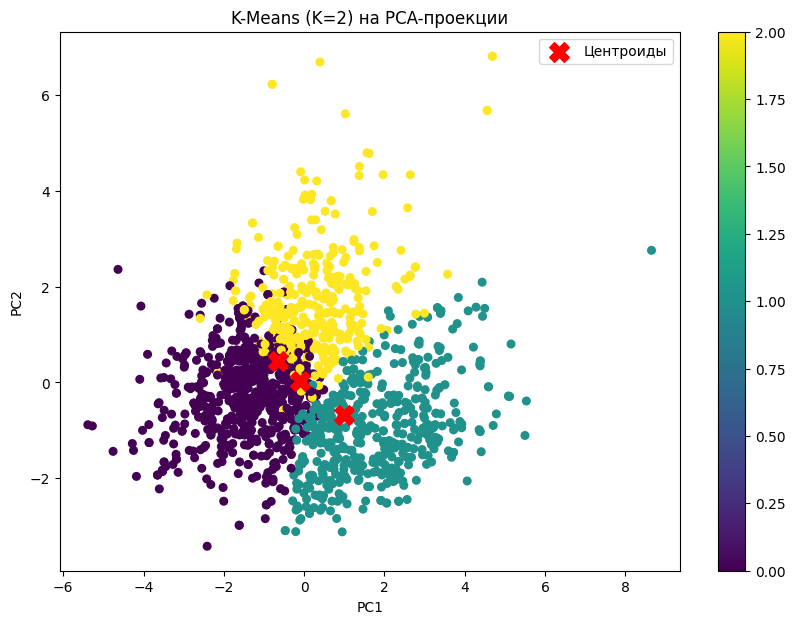

In [14]:
# С помощью PCA (2 компоненты) визуализируйте кластеры.
# Выведите силуэт финальной модели.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

# Часть 2 DBSCAN

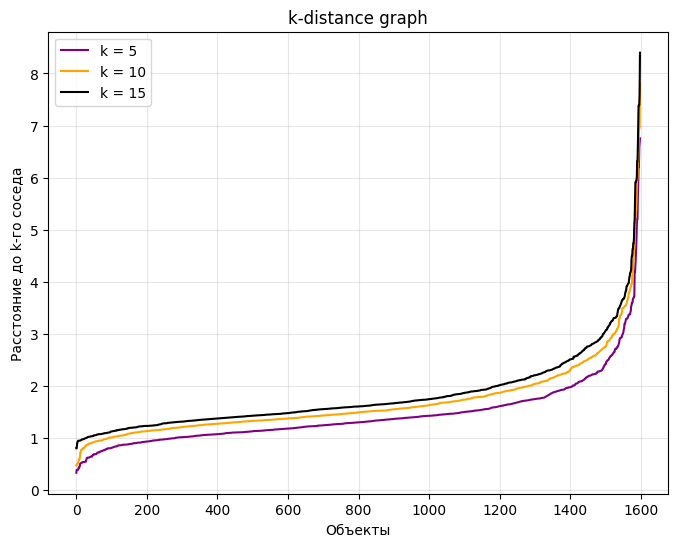

In [26]:
# Постройте k‑distance graph для min_samples = 5, 10, 15.

plt.figure(figsize=(8, 6))

colors = {
    5: "purple",
    10: "orange",
    15: "black"
}

for k in [5, 10, 15]:
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, _ = neighbors_fit.kneighbors(X_scaled)

    k_distances = np.sort(distances[:, -1])

    plt.plot(k_distances, color=colors[k], label=f"k = {k}")

plt.title("k-distance graph")
plt.xlabel("Объекты")
plt.ylabel("Расстояние до k-го соседа")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [29]:
# Методом перебора (eps от 0.3 до 1.1 с шагом 0.1, min_samples = 5, 10, 15) найдите параметры, дающие максимальный силуэт (число кластеров ≥ 2, шум не более 80% данных).

best_score = -1
best_params = None
best_labels = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in [5, 10, 15]:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})

        noise_ratio = list(labels).count(-1) / len(labels)

        if n_clusters < 2 or noise_ratio > 0.8:
          continue

        mask = labels != -1
        if len(set(labels[mask])) < 2:
            continue

        score = silhouette_score(X_scaled[mask], labels[mask])

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)
            best_labels = labels

print("Лучшие параметры:", best_params)
print("Максимальный силуэт:", best_score)

Лучшие параметры: (np.float64(1.1000000000000003), 10)
Максимальный силуэт: 0.24559029462188608


In [30]:
# Обучите DBSCAN с лучшими параметрами.

best_eps, best_min_samples = best_params

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_final = dbscan_final.fit_predict(X_scaled)

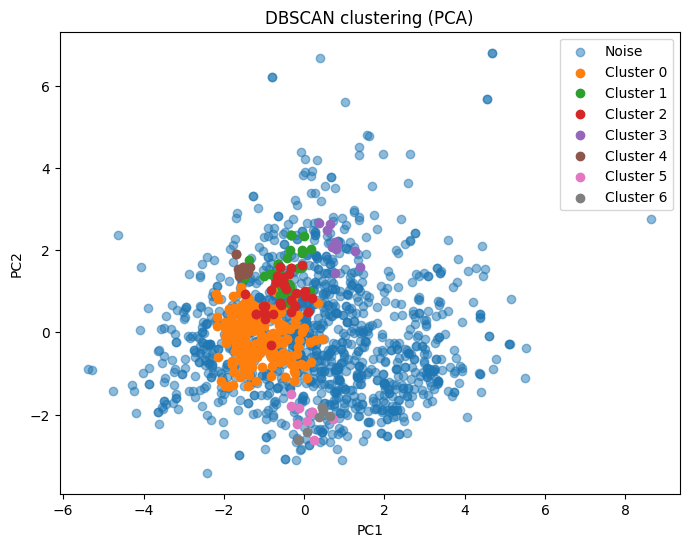

In [39]:
# Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

noise = labels_final == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], label="Noise", alpha=0.5)

clusters = set(labels_final) - {-1}
for cluster in clusters:
    mask = labels_final == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster}")

plt.legend()
plt.title("DBSCAN clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Ответы на вопросы**

*1. Почему для DBSCAN критически важно масштабировать данные?*


DBSCAN основан на вычислении расстояний между объектами. Если признаки имеют разный масштаб, то признаки с большими значениями будут сильнее влиять на расстояние. В результате алгоритм будет учитывать не все признаки равномерно, а кластеры могут определяться некорректно. Масштабирование делает расстояния сопоставимыми, и DBSCAN работает корректнее.

*2. Что будет при слишком маленьком eps? Слишком большом?*


При слишком маленьком eps большинство точек будут иметь недостаточно соседей в заданном радиусе и будут отнесены к шуму. Кластеры либо не сформируются, либо будут маленькими. При слишком большом eps многие точки окажутся связанными друг с другом, и алгоритм объединит их в один или несколько крупных кластеров. Из-за этого ухудшится качество кластеризации.

*3. Что означают точки с меткой -1?*


Точки с меткой -1 считаются шумом. Эти объекты не принадлежат ни к одному кластеру, т.к. в их окрестности недостаточно соседей. Такие точки могут быть аномальными или просто находиться в разреженных областях пространства признаков.

*4. Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?*


DBSCAN принципиально отличается от K‑Means тем, чьо алгоритм K-Means предполагает, что кластеры имеют приблизительно сферическую форму и разделяет данные на основе расстояния до центров кластеров. DBSCAN же выделяет кластеры как области повышенной плотности и способен находить кластеры произвольной формы. Также DBSCAN не требует заранее задавать число кластеров и умеет выделять шум, а K-Means этого не делает.

# Часть 3 OPTICS

In [32]:
# Обучите OPTICS на тех же данных с параметрами:
# min_samples = 10
# xi = 0.05
# min_cluster_size = 0.05

optics = OPTICS(
    min_samples=10,
    xi=0.05,
    min_cluster_size=0.05
)

labels_optics = optics.fit_predict(X_scaled)

In [33]:
# Выведите:
# количество найденных кластеров
# количество шумовых точек
# коэффициент силуэта

n_clusters = len(set(labels_optics) - {-1})

noise_count = list(labels_optics).count(-1)

mask = labels_optics != -1
if len(set(labels_optics[mask])) > 1:
    sil_score = silhouette_score(X_scaled[mask], labels_optics[mask])
else:
    sil_score = -1

print("Кластеров:", n_clusters)
print("Шумовых точек:", noise_count)
print("Силуэт:", sil_score)

Кластеров: 1
Шумовых точек: 0
Силуэт: -1


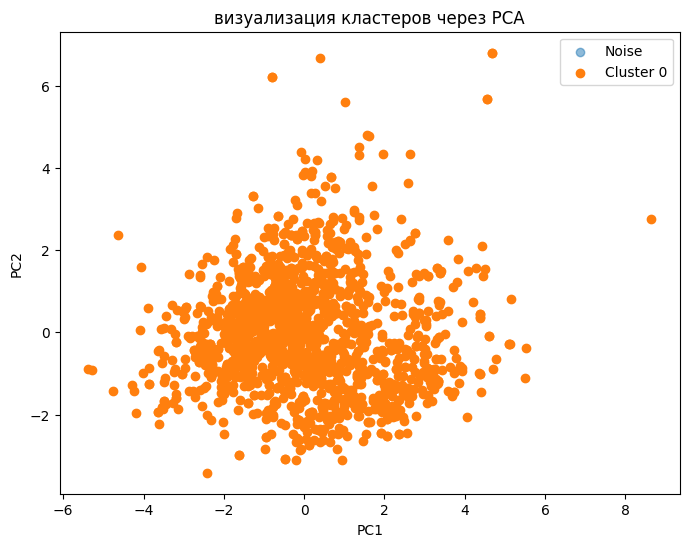

In [35]:
# Постройте:
# визуализацию кластеров через PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

noise = labels_optics == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], label="Noise", alpha=0.5)

for cluster in set(labels_optics) - {-1}:
    mask = labels_optics == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster}")

plt.legend()
plt.title("визуализация кластеров через PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

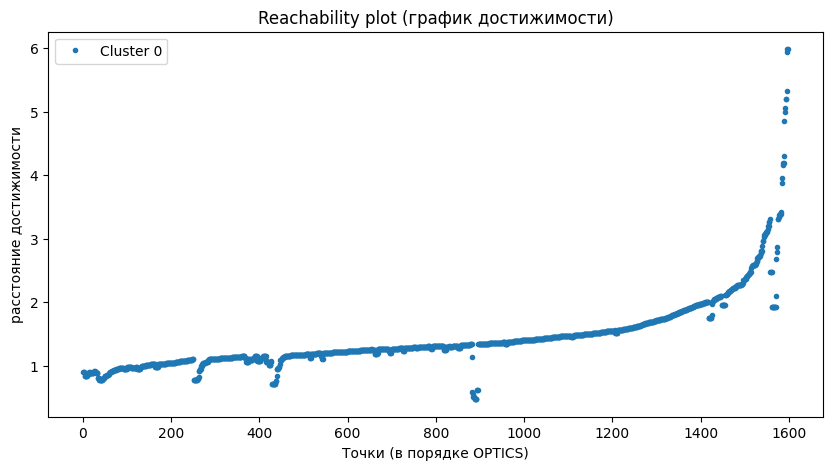

In [38]:
# reachability plot (график достижимости)
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

plt.figure(figsize=(10, 5))

for cluster in set(labels):
    mask = labels == cluster
    plt.plot(np.where(mask)[0], reachability[mask], '.', label=f"Cluster {cluster}")

plt.title("Reachability plot (график достижимости)")
plt.xlabel("Точки (в порядке OPTICS)")
plt.ylabel("расстояние достижимости")
plt.legend()
plt.show()

**Ответы на вопросы**

*1. Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.*


1. DBSCAN использует фиксированное значение параметра eps. OPTICS не требует жестко заданного eps, и анализирует структуру плотности данных на разных масштабах.

2. DBSCAN сразу выдает разбиение на кластеры, OPTICS сначала строит упорядочивание точек и рассчитывает расстояния достижимости и на их основе выделяет кластеры. OPTICS более гибкий в плане выбора параметров.


*2. Что такое параметр xi (кси) и как он влияет на выделение кластеров?*


Параметр xi определяет минимальную относительную резкость изменения плотности, необходимой для выделения границы кластера. Малые значения xi приводят к выделению большего числа кластеров, включая более мелкие структуры. Большие значения xi приводят к выделению только явно выраженных кластеров.


*3. В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.*


OPTICS показывает лучшие результаты в случаях, когда кластеры имеют различную плотность. Если в данных есть один плотный компактный кластер и один разреженный кластер, DBSCAN либо разобьет разреженный кластер на шум, либо соединит оба кластера в один. OPTICS в этом случае сможет корректно выделить оба кластера благодаря анализу плотности на разных уровнях.


*4. Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).*


DBSCAN работает быстрее, так как он выполняет более простые вычисления с фиксированным радиусом. OPTICS требует дополнительного этапа построения упорядочивания и вычисления reachability distance, из-за чего его время работы увеличено.


*5. Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?*


Если смотреть на визуализации, мне кажется, что лучше всех данные разделил K-Means. Визуально хорошо видно разделение на кластеры, что говорит о том, что алгоритм хорошо уловил структуру данных.